# Exercise 10 – Digital Biomarker Gait Analysis

## Scientific question

**Can smartphone motion sensors distinguish normal walking from unstable walking?**

Dataset assumptions:

- `experiment_id = 1` → normal walking
- `experiment_id = 2` → unstable walking
- Main sensor: `LSM6DSO Accelerometer`
- Optional supporting sensor: `LSM6DSO Gyroscope`

Important preprocessing decision:

The raw timestamps make **experiment 1 look much longer than expected** because there is a large gap inside the recording. This notebook therefore detects continuous recording segments, keeps the best usable segment for each experiment, trims both experiments to the same duration, and then compares the walking conditions.


## 1. Load libraries and JSON data

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.signal import find_peaks
    from scipy.stats import mannwhitneyu
except ImportError as exc:
    raise ImportError("Install scipy first: pip install scipy") from exc

# Put data.json in the same folder as this notebook.
DATA_PATH = Path("data.json")

with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw = json.load(f)

print(f"Loaded {len(raw)} sensor records from {DATA_PATH}")
raw[0]


Loaded 1420 sensor records from data.json


{'id': '0a13ec2c-599f-11f1-bf36-04d4c449342f',
 'patient_id': 1,
 'experiment_id': 1,
 'data': {'accuracy': 3,
  'data': [-0.8632108, 6.133403, 7.520642],
  'device': 'samsung SM-G990B2',
  'experimentId': 1,
  'friendlyTimeStamp': '2026-06-23 01:33:57.689',
  'patientId': 1,
  'sensorId': 'LSM6DSO Accelerometer',
  'sensorType': 1,
  'timestamp': 3700972724956233}}

## 2. Flatten the nested JSON

The exported JSON has one row per sensor measurement. The actual x/y/z sensor values are stored inside the nested field `data["data"]`.

This cell converts the JSON into a normal table.


In [ ]:
rows = []

for record in raw:
    d = record.get("data", {})
    values = d.get("data", [np.nan, np.nan, np.nan])

    rows.append({
        "id": record.get("id"),
        "patient_id": record.get("patient_id", d.get("patientId")),
        "experiment_id": record.get("experiment_id", d.get("experimentId")),
        "sensor_id": d.get("sensorId"),
        "sensor_type": d.get("sensorType"),
        "accuracy": d.get("accuracy"),
        "device": d.get("device"),
        "friendly_timestamp": d.get("friendlyTimeStamp"),
        "timestamp_ns": d.get("timestamp"),
        "x": values[0] if len(values) > 0 else np.nan,
        "y": values[1] if len(values) > 1 else np.nan,
        "z": values[2] if len(values) > 2 else np.nan,
    })

df = pd.DataFrame(rows)

df["dt"] = pd.to_datetime(df["friendly_timestamp"], errors="coerce")
df["activity"] = df["experiment_id"].map({
    1: "normal_walking",
    2: "unstable_walking",
})

df.head()


,id,patient_id,experiment_id,sensor_id,sensor_type,accuracy,device,friendly_timestamp,timestamp_ns,x,y,z,dt,activity
0,0a13ec2c-599f-11f1-bf36-04d4c449342f,1,1,LSM6DSO Accelerometer,1,3,samsung SM-G990B2,2026-06-23 01:33:57.689,3700972724956233,-0.863211,6.133403,7.520642,2026-06-23 01:33:57.689,normal_walking
1,0a139e15-599f-11f1-beea-04d4c449342f,1,1,LSM6DSO Accelerometer,1,3,samsung SM-G990B2,2026-06-23 01:33:57.765,3700972802172899,-0.945763,6.178866,7.609774,2026-06-23 01:33:57.765,normal_walking
2,0a14d6a0-599f-11f1-97dd-04d4c449342f,1,1,LSM6DSO Accelerometer,1,3,samsung SM-G990B2,2026-06-23 01:33:57.823,3700972860085399,-0.863809,6.126823,7.878368,2026-06-23 01:33:57.823,normal_walking
3,0a15248b-599f-11f1-86c2-04d4c449342f,1,1,LSM6DSO Gyroscope,4,3,samsung SM-G990B2,2026-06-23 01:33:57.741,3700972777271337,0.001298,-0.003971,-0.000687,2026-06-23 01:33:57.741,normal_walking
4,0a165d08-599f-11f1-a353-04d4c449342f,1,1,LSM6DSO Accelerometer,1,3,samsung SM-G990B2,2026-06-23 01:33:57.901,3700972937302066,-0.906282,6.165706,7.731210,2026-06-23 01:33:57.901,normal_walking


## 3. First quality check

This section intentionally shows the **raw** situation before cleaning.

If one experiment appears to have a very different sampling rate, this is often caused by a large time gap inside the same `experiment_id`. Therefore, we check the duration and sampling rate before doing any analysis.


In [ ]:
raw_summary = (
    df.groupby(["experiment_id", "activity", "sensor_id"])
      .agg(
          n_samples=("id", "count"),
          start_time=("dt", "min"),
          end_time=("dt", "max"),
          timestamp_min=("timestamp_ns", "min"),
          timestamp_max=("timestamp_ns", "max"),
      )
      .reset_index()
)

raw_summary["duration_from_friendly_time_sec"] = (
    raw_summary["end_time"] - raw_summary["start_time"]
).dt.total_seconds()

raw_summary["duration_from_sensor_timestamp_sec"] = (
    raw_summary["timestamp_max"] - raw_summary["timestamp_min"]
) / 1e9

raw_summary["raw_sampling_rate_hz"] = (
    raw_summary["n_samples"] / raw_summary["duration_from_sensor_timestamp_sec"]
)

raw_summary


,experiment_id,activity,sensor_id,n_samples,start_time,end_time,timestamp_min,timestamp_max,duration_from_friendly_time_sec,duration_from_sensor_timestamp_sec,raw_sampling_rate_hz
0,1,normal_walking,LSM6DSO Accelerometer,839,2026-06-23 01:33:57.650,2026-06-23 01:35:27.492,3700972686347899,3701045579010048,89.842,72.892662,11.510075
1,1,normal_walking,LSM6DSO Gyroscope,80,2026-06-23 01:33:57.741,2026-06-23 01:35:27.394,3700972777271337,3701045481717705,89.653,72.704446,1.100345
2,2,unstable_walking,LSM6DSO Accelerometer,457,2026-06-23 01:35:36.488,2026-06-23 01:35:45.368,3701054575068486,3701063455269111,8.880,8.880201,51.462801
3,2,unstable_walking,LSM6DSO Gyroscope,44,2026-06-23 01:35:36.603,2026-06-23 01:35:45.320,3701054690130517,3701063406238434,8.717,8.716108,5.048125


## 4. Detect large gaps inside each experiment

For the accelerometer, the expected sampling interval is about 0.019 seconds, which is roughly 52 Hz.

If there is a gap much larger than that, the app likely stored two separate chunks under the same experiment ID or paused/stalled during recording.

Here, any gap greater than **1 second** starts a new continuous segment.


In [ ]:
ACCELEROMETER_PATTERN = "Accelerometer"

acc_raw = (
    df[df["sensor_id"].str.contains(ACCELEROMETER_PATTERN, case=False, na=False)]
    .sort_values(["experiment_id", "timestamp_ns"])
    .copy()
)

acc_raw["gap_s"] = acc_raw.groupby("experiment_id")["timestamp_ns"].diff() / 1e9

acc_raw["segment_id"] = (
    acc_raw["gap_s"]
    .gt(1.0)
    .fillna(False)
    .groupby(acc_raw["experiment_id"])
    .cumsum()
    + 1
).astype(int)

segment_summary = (
    acc_raw.groupby(["experiment_id", "activity", "segment_id"])
    .agg(
        n_samples=("id", "count"),
        start_time=("dt", "min"),
        end_time=("dt", "max"),
        timestamp_start=("timestamp_ns", "min"),
        timestamp_end=("timestamp_ns", "max"),
        max_gap_inside_segment_s=("gap_s", "max"),
    )
    .reset_index()
)

segment_summary["duration_sec"] = (
    segment_summary["timestamp_end"] - segment_summary["timestamp_start"]
) / 1e9

segment_summary["sampling_rate_hz"] = (
    segment_summary["n_samples"] / segment_summary["duration_sec"]
)

segment_summary


,experiment_id,activity,segment_id,n_samples,start_time,end_time,timestamp_start,timestamp_end,max_gap_inside_segment_s,duration_sec,sampling_rate_hz
0,1,normal_walking,1,197,2026-06-23 01:33:57.650,2026-06-23 01:34:01.433,3700972686347899,3700976469970191,0.019304,3.783622,52.066508
1,1,normal_walking,2,642,2026-06-23 01:35:15.117,2026-06-23 01:35:27.492,3701033204778382,3701045579010048,56.734808,12.374232,51.882009
2,2,unstable_walking,1,457,2026-06-23 01:35:36.488,2026-06-23 01:35:45.368,3701054575068486,3701063455269111,0.096523,8.880201,51.462801


## 5. Select the usable continuous recording for each experiment

Because the task is to compare normal and unstable walking, we need one clean continuous segment per experiment.

Selection rule used here:

1. Prefer segments that are at least 5 seconds long.
2. Within those, choose the longest segment.
3. Later, trim both conditions to the same duration for a fair comparison.

For this file, this should remove the short broken/partial part of experiment 1 and keep the longer normal-walking segment.


In [ ]:
selected_segments = []

for experiment_id, group in segment_summary.groupby("experiment_id"):
    candidates = group[group["duration_sec"] >= 5].copy()

    if candidates.empty:
        candidates = group.copy()

    chosen = candidates.sort_values("duration_sec", ascending=False).iloc[0]
    selected_segments.append(chosen)

selected_segments = pd.DataFrame(selected_segments).reset_index(drop=True)

selected_segments[[
    "experiment_id",
    "activity",
    "segment_id",
    "n_samples",
    "duration_sec",
    "sampling_rate_hz",
    "start_time",
    "end_time",
]]


,experiment_id,activity,segment_id,n_samples,duration_sec,sampling_rate_hz,start_time,end_time
0,1,normal_walking,2,642,12.374232,51.882009,2026-06-23 01:35:15.117,2026-06-23 01:35:27.492
1,2,unstable_walking,1,457,8.880201,51.462801,2026-06-23 01:35:36.488,2026-06-23 01:35:45.368


## 6. Filter the full dataset to the selected segments

The accelerometer is used to define the clean segment boundaries. Then all sensors belonging to the same experiment and time range are kept.

This allows the gyroscope data to be used as supporting information.


In [ ]:
selected_parts = []

for _, segment in selected_segments.iterrows():
    experiment_id = segment["experiment_id"]
    start_ts = segment["timestamp_start"]
    end_ts = segment["timestamp_end"]

    part = df[
        (df["experiment_id"] == experiment_id)
        & (df["timestamp_ns"] >= start_ts)
        & (df["timestamp_ns"] <= end_ts)
    ].copy()

    part["selected_segment_id"] = int(segment["segment_id"])
    selected_parts.append(part)

clean_df = pd.concat(selected_parts, ignore_index=True)

clean_df = clean_df.sort_values([
    "experiment_id",
    "sensor_id",
    "timestamp_ns"
]).reset_index(drop=True)

# Relative time starts at 0 separately for each experiment and sensor.
clean_df["t_sec"] = (
    clean_df["timestamp_ns"]
    - clean_df.groupby(["experiment_id", "sensor_id"])["timestamp_ns"].transform("min")
) / 1e9

clean_summary = (
    clean_df.groupby(["experiment_id", "activity", "sensor_id"])
    .agg(
        n_samples=("id", "count"),
        duration_sec=("t_sec", "max"),
        start_time=("dt", "min"),
        end_time=("dt", "max"),
    )
    .reset_index()
)

clean_summary["sampling_rate_hz"] = (
    clean_summary["n_samples"] / clean_summary["duration_sec"]
)

clean_summary


,experiment_id,activity,sensor_id,n_samples,duration_sec,start_time,end_time,sampling_rate_hz
0,1,normal_walking,LSM6DSO Accelerometer,642,12.374232,2026-06-23 01:35:15.117,2026-06-23 01:35:27.492,51.882009
1,1,normal_walking,LSM6DSO Gyroscope,61,12.161885,2026-06-23 01:35:15.233,2026-06-23 01:35:27.394,5.015670
2,2,unstable_walking,LSM6DSO Accelerometer,457,8.880201,2026-06-23 01:35:36.488,2026-06-23 01:35:45.368,51.462801
3,2,unstable_walking,LSM6DSO Gyroscope,44,8.716108,2026-06-23 01:35:36.603,2026-06-23 01:35:45.320,5.048125


## 7. Trim both experiments to the same duration

The normal walking segment is longer than the unstable walking segment. To avoid bias, compare only the same time length from both experiments.

The notebook uses the shortest available accelerometer duration as the common duration.


In [ ]:
acc_clean = clean_df[
    clean_df["sensor_id"].str.contains(ACCELEROMETER_PATTERN, case=False, na=False)
].copy()

common_duration_sec = acc_clean.groupby("experiment_id")["t_sec"].max().min()

analysis_df = clean_df[clean_df["t_sec"] <= common_duration_sec].copy()

print(f"Common comparison duration: {common_duration_sec:.2f} seconds")

analysis_df.groupby(["experiment_id", "activity", "sensor_id"]).agg(
    n_samples=("id", "count"),
    duration_sec=("t_sec", "max"),
)


Common comparison duration: 8.88 seconds


n_samples  duration_sec
experiment_id activity         sensor_id                                     
1             normal_walking   LSM6DSO Accelerometer        461      8.880073
                               LSM6DSO Gyroscope             44      8.715987
2             unstable_walking LSM6DSO Accelerometer        457      8.880201
                               LSM6DSO Gyroscope             44      8.716108

## 8. Resample accelerometer to a common rate

Even after cleaning, small sampling-rate differences can remain. For a fair comparison, the accelerometer data is resampled to **50 Hz**.

This is close to the observed accelerometer sampling rate in both experiments.


In [ ]:
TARGET_FS = 50  # Hz

acc_analysis = analysis_df[
    analysis_df["sensor_id"].str.contains(ACCELEROMETER_PATTERN, case=False, na=False)
].copy()

def resample_accelerometer(group, target_fs=50, duration=None):
    group = group.sort_values("t_sec").drop_duplicates("t_sec").copy()

    if duration is None:
        duration = group["t_sec"].max()

    new_t = np.arange(0, duration, 1 / target_fs)

    out = pd.DataFrame({
        "experiment_id": group["experiment_id"].iloc[0],
        "activity": group["activity"].iloc[0],
        "t_sec": new_t,
    })

    for axis in ["x", "y", "z"]:
        out[axis] = np.interp(new_t, group["t_sec"], group[axis])

    return out

acc_resampled = pd.concat(
    [
        resample_accelerometer(group, TARGET_FS, common_duration_sec)
        for _, group in acc_analysis.groupby("experiment_id")
    ],
    ignore_index=True
)

acc_resampled["acc_mag"] = np.sqrt(
    acc_resampled["x"]**2
    + acc_resampled["y"]**2
    + acc_resampled["z"]**2
)

# Remove slow baseline changes with a 1-second rolling median.
# This gives a dynamic movement signal that is easier to compare.
rolling_window = TARGET_FS

acc_resampled["baseline_mag"] = (
    acc_resampled.groupby("experiment_id")["acc_mag"]
    .transform(lambda s: s.rolling(rolling_window, center=True, min_periods=1).median())
)

acc_resampled["dynamic_acc"] = (
    acc_resampled["acc_mag"] - acc_resampled["baseline_mag"]
)

acc_resampled.head()


,experiment_id,activity,t_sec,x,y,z,acc_mag,baseline_mag,dynamic_acc
0,1,normal_walking,0.00,-3.281756,2.021935,7.387840,8.332966,9.170550,-0.837584
1,1,normal_walking,0.02,-2.615542,2.151637,8.090593,8.770878,9.772471,-1.001593
2,1,normal_walking,0.04,-2.148597,1.872758,8.538788,9.001922,10.374391,-1.372469
3,1,normal_walking,0.06,-2.044133,1.607410,8.096476,8.503833,10.841851,-2.338019
4,1,normal_walking,0.08,-1.994570,1.510730,7.320933,7.736710,10.719724,-2.983014


## 9. Plot acceleration magnitude

This plot is the easiest visual answer to the task.

Normal walking should usually show more regular acceleration peaks. Unstable walking is expected to show more irregular peak timing and often stronger variability.


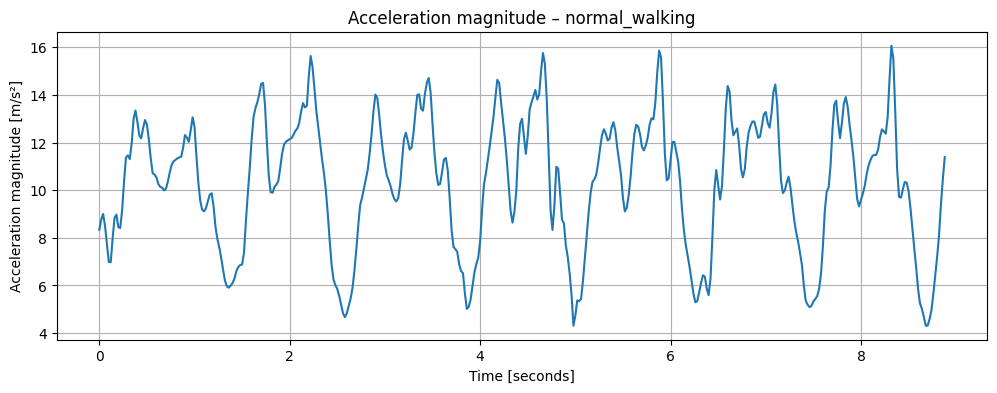

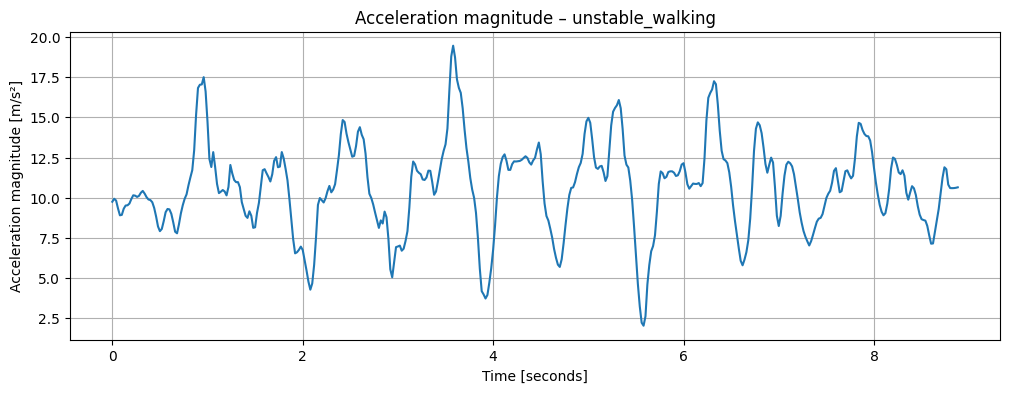

In [ ]:
for experiment_id, group in acc_resampled.groupby("experiment_id"):
    label = group["activity"].iloc[0]

    plt.figure(figsize=(12, 4))
    plt.plot(group["t_sec"], group["acc_mag"])
    plt.title(f"Acceleration magnitude – {label}")
    plt.xlabel("Time [seconds]")
    plt.ylabel("Acceleration magnitude [m/s²]")
    plt.grid(True)
    plt.show()


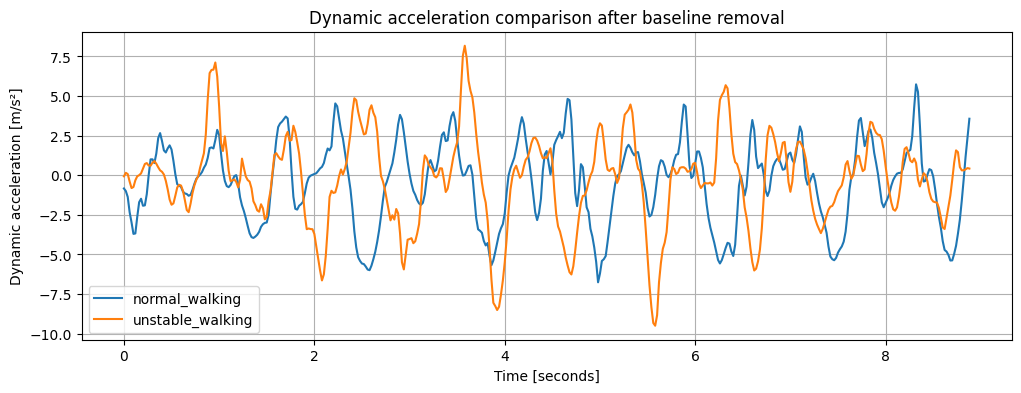

In [ ]:
plt.figure(figsize=(12, 4))

for experiment_id, group in acc_resampled.groupby("experiment_id"):
    label = group["activity"].iloc[0]
    plt.plot(group["t_sec"], group["dynamic_acc"], label=label)

plt.title("Dynamic acceleration comparison after baseline removal")
plt.xlabel("Time [seconds]")
plt.ylabel("Dynamic acceleration [m/s²]")
plt.legend()
plt.grid(True)
plt.show()


## 10. Extract digital-biomarker features

Features used:

| Feature | Interpretation |
|---|---|
| `std_acc_mag` | Variability of movement |
| `iqr_acc_mag` | Robust variability of movement |
| `range_acc_mag` | Difference between strongest and weakest acceleration |
| `rms_dynamic_acc` | Overall dynamic movement intensity |
| `mean_abs_jerk` | Abruptness of movement changes |
| `n_detected_peaks` | Approximate number of gait impact peaks |
| `cadence_peaks_per_min` | Approximate step/impact rhythm |
| `step_interval_cv` | Irregularity of detected peak intervals |

For unstable walking, the expected pattern is especially higher variability, higher jerk, and higher `step_interval_cv`.


In [ ]:
def extract_acc_features(group, target_fs=50):
    group = group.sort_values("t_sec").copy()

    t = group["t_sec"].to_numpy()
    acc_mag = group["acc_mag"].to_numpy()
    dynamic_acc = group["dynamic_acc"].to_numpy()

    duration = t.max() - t.min()

    jerk = np.diff(acc_mag) * target_fs

    # Peak detection is intentionally conservative.
    # The prominence adapts to the signal variability.
    prominence = max(0.5, 0.6 * np.std(acc_mag))
    min_distance_samples = int(0.30 * target_fs)

    peaks, _ = find_peaks(
        acc_mag,
        distance=min_distance_samples,
        prominence=prominence
    )

    peak_times = t[peaks]
    step_intervals = np.diff(peak_times)

    step_interval_cv = np.nan
    mean_step_interval = np.nan

    if len(step_intervals) > 1 and np.mean(step_intervals) > 0:
        mean_step_interval = np.mean(step_intervals)
        step_interval_cv = np.std(step_intervals) / np.mean(step_intervals)

    return pd.Series({
        "duration_sec": duration,
        "std_acc_mag": np.std(acc_mag, ddof=1),
        "iqr_acc_mag": np.percentile(acc_mag, 75) - np.percentile(acc_mag, 25),
        "range_acc_mag": np.max(acc_mag) - np.min(acc_mag),
        "rms_dynamic_acc": np.sqrt(np.mean(dynamic_acc**2)),
        "mean_abs_jerk": np.mean(np.abs(jerk)),
        "n_detected_peaks": len(peaks),
        "cadence_peaks_per_min": len(peaks) / duration * 60 if duration > 0 else np.nan,
        "mean_step_interval_sec": mean_step_interval,
        "step_interval_cv": step_interval_cv,
    })

feature_rows = []

for (experiment_id, activity), group in acc_resampled.groupby(["experiment_id", "activity"]):
    features = extract_acc_features(group, TARGET_FS)
    features["experiment_id"] = experiment_id
    features["activity"] = activity
    feature_rows.append(features)

features = pd.DataFrame(feature_rows)

# Put label columns first
features = features[["experiment_id", "activity"] + [
    col for col in features.columns 
    if col not in ["experiment_id", "activity"]
]]

features


,experiment_id,activity,duration_sec,std_acc_mag,iqr_acc_mag,range_acc_mag,rms_dynamic_acc,mean_abs_jerk,n_detected_peaks,cadence_peaks_per_min,mean_step_interval_sec,step_interval_cv
0,1.0,normal_walking,8.88,2.761358,3.978642,11.758316,2.615008,28.136042,14.0,94.594595,0.610769,0.180096
1,2.0,unstable_walking,8.88,2.800542,3.229892,17.411859,2.909901,29.356386,13.0,87.837838,0.603333,0.374266


## 11. Visualize detected peaks

This checks whether the peak detection is reasonable. If the detected peaks look wrong, adjust the `prominence` value in the previous cell.


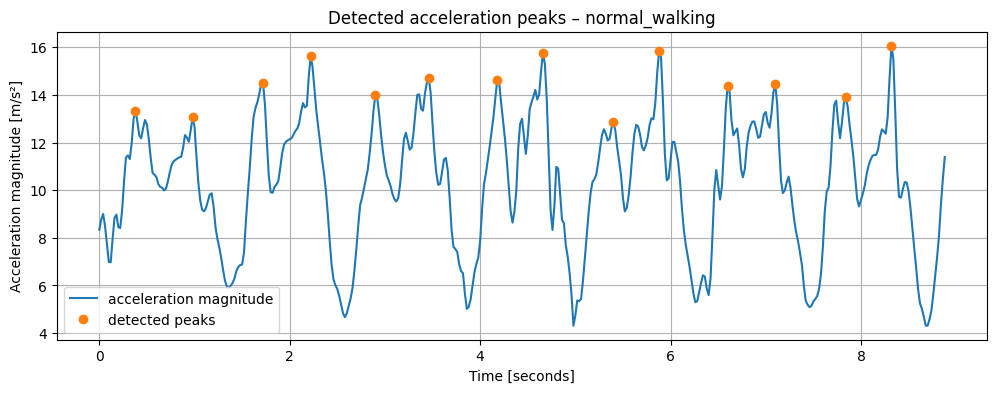

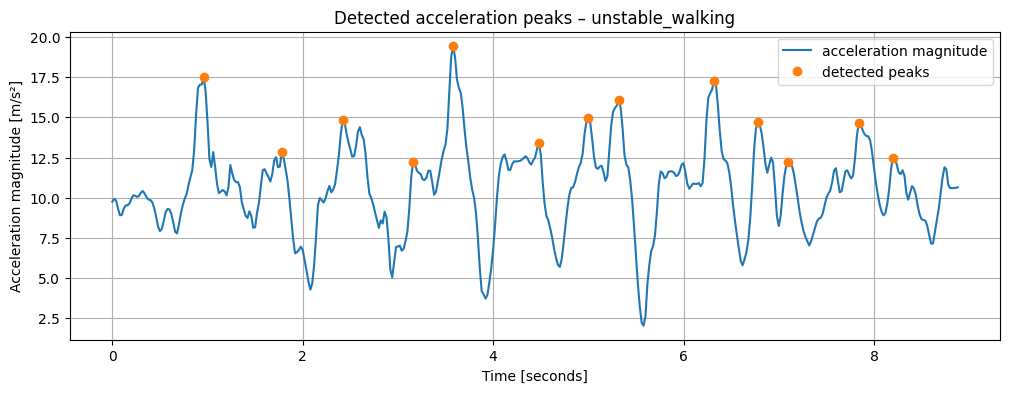

In [ ]:
for experiment_id, group in acc_resampled.groupby("experiment_id"):
    group = group.sort_values("t_sec").copy()
    label = group["activity"].iloc[0]

    acc_mag = group["acc_mag"].to_numpy()
    t = group["t_sec"].to_numpy()

    prominence = max(0.5, 0.6 * np.std(acc_mag))
    min_distance_samples = int(0.30 * TARGET_FS)

    peaks, _ = find_peaks(
        acc_mag,
        distance=min_distance_samples,
        prominence=prominence
    )

    plt.figure(figsize=(12, 4))
    plt.plot(t, acc_mag, label="acceleration magnitude")
    plt.plot(t[peaks], acc_mag[peaks], "o", label="detected peaks")
    plt.title(f"Detected acceleration peaks – {label}")
    plt.xlabel("Time [seconds]")
    plt.ylabel("Acceleration magnitude [m/s²]")
    plt.legend()
    plt.grid(True)
    plt.show()


## 12. Window-based comparison

Because this is a small sample dataset, we do not have many participants. A useful exercise-level approach is to split the time series into short windows, for example 2-second windows.

This gives several observations per condition and makes the comparison more visible.


In [ ]:
WINDOW_SIZE_SEC = 2

acc_resampled["window_id"] = (acc_resampled["t_sec"] // WINDOW_SIZE_SEC).astype(int)

def extract_window_features(group):
    group = group.sort_values("t_sec").copy()

    acc_mag = group["acc_mag"].to_numpy()
    dynamic_acc = group["dynamic_acc"].to_numpy()

    jerk = np.diff(acc_mag) * TARGET_FS

    return pd.Series({
        "n_samples": len(group),
        "duration_sec": group["t_sec"].max() - group["t_sec"].min(),
        "std_acc_mag": np.std(acc_mag, ddof=1),
        "iqr_acc_mag": np.percentile(acc_mag, 75) - np.percentile(acc_mag, 25),
        "range_acc_mag": np.max(acc_mag) - np.min(acc_mag),
        "rms_dynamic_acc": np.sqrt(np.mean(dynamic_acc**2)),
        "mean_abs_jerk": np.mean(np.abs(jerk)) if len(jerk) > 0 else np.nan,
    })

window_rows = []

for keys, group in acc_resampled.groupby(["experiment_id", "activity", "window_id"]):
    experiment_id, activity, window_id = keys
    row = extract_window_features(group)
    row["experiment_id"] = experiment_id
    row["activity"] = activity
    row["window_id"] = window_id
    window_rows.append(row)

window_features = pd.DataFrame(window_rows)

# Remove incomplete windows at the end
window_features = window_features[
    window_features["duration_sec"] >= WINDOW_SIZE_SEC * 0.8
].copy()

window_features = window_features[[
    "experiment_id",
    "activity",
    "window_id",
    "n_samples",
    "duration_sec",
    "std_acc_mag",
    "iqr_acc_mag",
    "range_acc_mag",
    "rms_dynamic_acc",
    "mean_abs_jerk",
]]

window_features


,experiment_id,activity,window_id,n_samples,duration_sec,std_acc_mag,iqr_acc_mag,range_acc_mag,rms_dynamic_acc,mean_abs_jerk
0,1.0,normal_walking,0,100.0,1.98,2.192540,3.278235,8.599180,2.026698,21.760666
1,1.0,normal_walking,1,100.0,1.98,3.040309,5.103325,10.968351,3.003970,25.637776
2,1.0,normal_walking,2,100.0,1.98,2.591105,3.214452,11.552717,2.463293,34.457758
3,1.0,normal_walking,3,100.0,1.98,2.871888,5.017411,9.352279,2.749267,29.798366
5,2.0,unstable_walking,0,100.0,1.98,2.192078,2.381194,10.955318,2.188176,24.475361
6,2.0,unstable_walking,1,100.0,1.98,3.595624,5.122932,15.718967,3.853649,34.432222
7,2.0,unstable_walking,2,100.0,1.98,3.064062,3.323249,14.035036,3.271275,31.045504
8,2.0,unstable_walking,3,100.0,1.98,2.580869,3.065737,11.445746,2.522187,30.303247


C:\Users\spunk\AppData\Local\Temp\ipykernel_14100\3061706202.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=plot_labels)


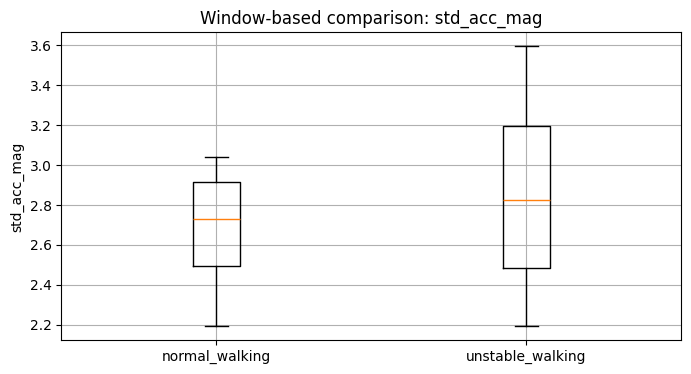

C:\Users\spunk\AppData\Local\Temp\ipykernel_14100\3061706202.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=plot_labels)


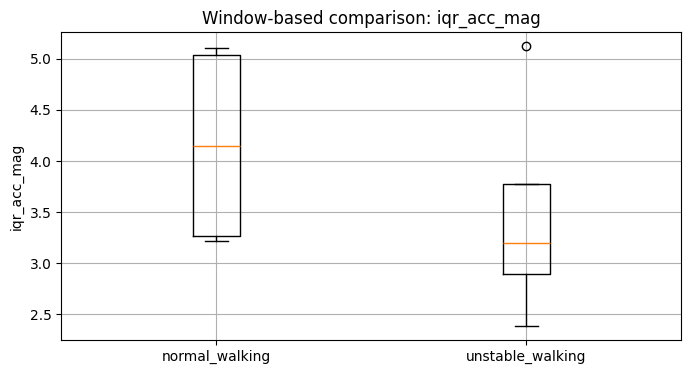

C:\Users\spunk\AppData\Local\Temp\ipykernel_14100\3061706202.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=plot_labels)


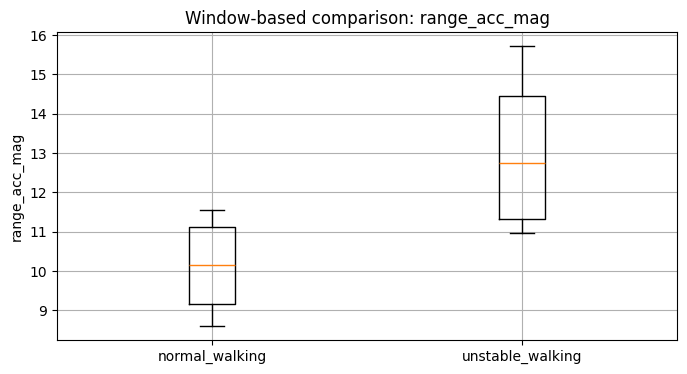

C:\Users\spunk\AppData\Local\Temp\ipykernel_14100\3061706202.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=plot_labels)


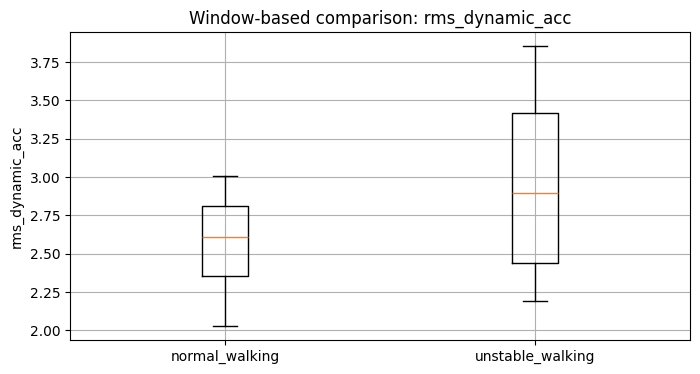

C:\Users\spunk\AppData\Local\Temp\ipykernel_14100\3061706202.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=plot_labels)


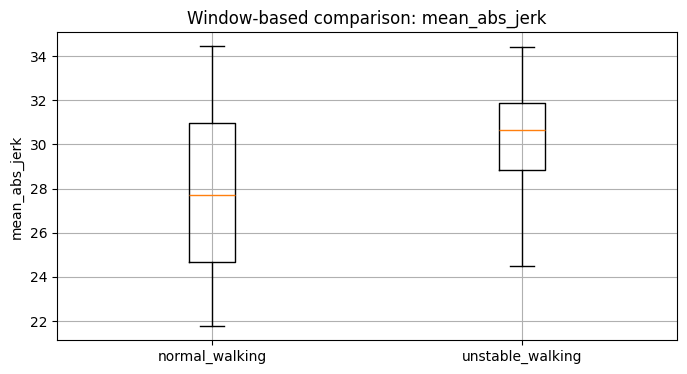

In [ ]:
metrics = [
    "std_acc_mag",
    "iqr_acc_mag",
    "range_acc_mag",
    "rms_dynamic_acc",
    "mean_abs_jerk",
]

for metric in metrics:
    plt.figure(figsize=(8, 4))

    plot_data = []
    plot_labels = []

    for activity, group in window_features.groupby("activity"):
        plot_data.append(group[metric].dropna().to_numpy())
        plot_labels.append(activity)

    plt.boxplot(plot_data, labels=plot_labels)
    plt.title(f"Window-based comparison: {metric}")
    plt.ylabel(metric)
    plt.grid(True)
    plt.show()


## 13. Statistical comparison

This is only illustrative because the dataset is small and comes from one person. For a real medical study, you would need more participants and repeated trials.

Here, a Mann–Whitney U test compares the 2-second windows from normal and unstable walking.


In [ ]:
stat_results = []

for metric in metrics:
    normal = window_features.loc[
        window_features["experiment_id"] == 1, metric
    ].dropna()

    unstable = window_features.loc[
        window_features["experiment_id"] == 2, metric
    ].dropna()

    if len(normal) > 1 and len(unstable) > 1:
        statistic, p_value = mannwhitneyu(normal, unstable, alternative="two-sided")
    else:
        statistic, p_value = np.nan, np.nan

    stat_results.append({
        "metric": metric,
        "normal_median": normal.median(),
        "unstable_median": unstable.median(),
        "difference_unstable_minus_normal": unstable.median() - normal.median(),
        "p_value": p_value,
    })

stat_results = pd.DataFrame(stat_results)
stat_results


,metric,normal_median,unstable_median,difference_unstable_minus_normal,p_value
0,std_acc_mag,2.731497,2.822465,0.090969,0.885714
1,iqr_acc_mag,4.147823,3.194493,-0.953330,0.685714
2,range_acc_mag,10.160315,12.740391,2.580076,0.200000
3,rms_dynamic_acc,2.606280,2.896731,0.290451,0.485714
4,mean_abs_jerk,27.718071,30.674376,2.956305,0.685714


## 14. Optional: gyroscope summary

The gyroscope has a lower sampling rate than the accelerometer, but it can still support the interpretation because it measures rotation.

Unstable walking may show larger rotational motion or more irregular rotational changes.


,experiment_id,activity,n_samples,duration_sec,mean_gyro_mag,std_gyro_mag,max_gyro_mag,sampling_rate_hz
0,1,normal_walking,44,8.715987,1.246561,0.584473,2.532761,5.048195
1,2,unstable_walking,44,8.716108,1.441476,0.751877,3.423256,5.048125


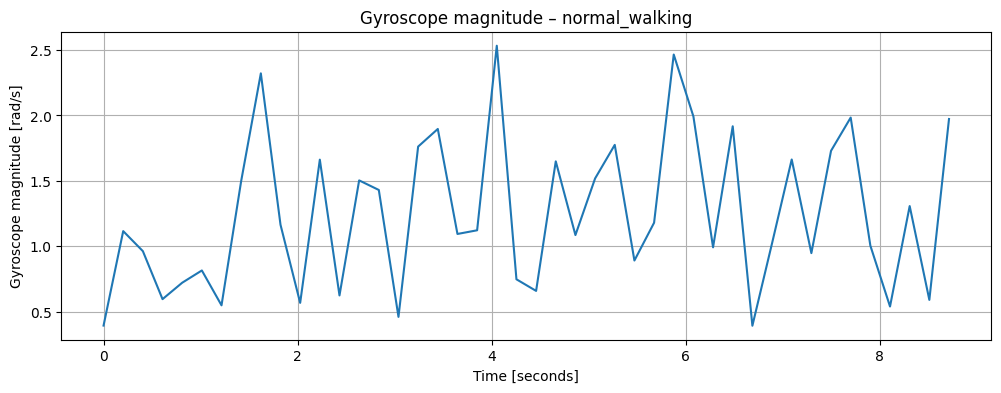

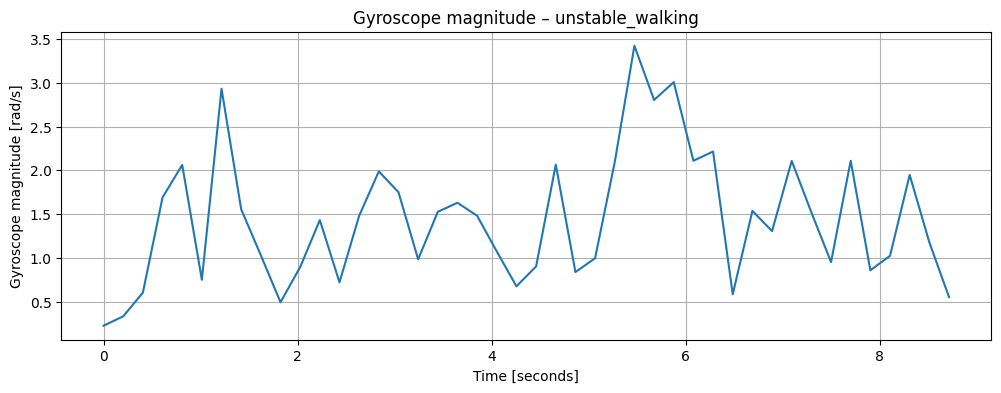

In [ ]:
GYROSCOPE_PATTERN = "Gyroscope"

gyro = analysis_df[
    analysis_df["sensor_id"].str.contains(GYROSCOPE_PATTERN, case=False, na=False)
].copy()

if gyro.empty:
    print("No gyroscope data found.")
else:
    gyro["gyro_mag"] = np.sqrt(gyro["x"]**2 + gyro["y"]**2 + gyro["z"]**2)

    gyro_features = (
        gyro.groupby(["experiment_id", "activity"])
        .agg(
            n_samples=("id", "count"),
            duration_sec=("t_sec", "max"),
            mean_gyro_mag=("gyro_mag", "mean"),
            std_gyro_mag=("gyro_mag", "std"),
            max_gyro_mag=("gyro_mag", "max"),
        )
        .reset_index()
    )

    gyro_features["sampling_rate_hz"] = (
        gyro_features["n_samples"] / gyro_features["duration_sec"]
    )

    display(gyro_features)

    for experiment_id, group in gyro.groupby("experiment_id"):
        label = group["activity"].iloc[0]
        plt.figure(figsize=(12, 4))
        plt.plot(group["t_sec"], group["gyro_mag"])
        plt.title(f"Gyroscope magnitude – {label}")
        plt.xlabel("Time [seconds]")
        plt.ylabel("Gyroscope magnitude [rad/s]")
        plt.grid(True)
        plt.show()


## 15. Automatic interpretation helper

This cell creates a short text interpretation that can be copied into your report or presentation.


In [ ]:
# Build an interpretation based on the main features.
wide_features = features.set_index("activity")

normal_label = "normal_walking"
unstable_label = "unstable_walking"

if normal_label in wide_features.index and unstable_label in wide_features.index:
    comparison = (
        wide_features.loc[unstable_label, metrics + ["step_interval_cv"]]
        - wide_features.loc[normal_label, metrics + ["step_interval_cv"]]
    )

    print("Feature difference: unstable walking minus normal walking")
    display(comparison.to_frame("difference"))

    print("\nInterpretation template:")
    print(
        "The analysis used the accelerometer as the primary sensor and the gyroscope as a supporting sensor. "
        "The broken sampling-rate problem was handled by detecting large gaps, selecting one continuous segment "
        "per experiment, trimming both experiments to the same duration, and resampling the accelerometer to 50 Hz. "
        "The resulting features compare normal and unstable walking using movement variability, dynamic acceleration, "
        "jerk, and peak-interval irregularity."
    )

    if comparison.get("step_interval_cv", 0) > 0:
        print(
            "In this dataset, the unstable walking recording has a higher step-interval variability than normal walking, "
            "which supports the idea that smartphone sensor data can capture gait irregularity."
        )
else:
    print("Both normal_walking and unstable_walking are required for the automatic interpretation.")


Feature difference: unstable walking minus normal walking


,difference
std_acc_mag,0.039184
iqr_acc_mag,-0.748750
range_acc_mag,5.653543
rms_dynamic_acc,0.294893
mean_abs_jerk,1.220344
step_interval_cv,0.194170



Interpretation template:
The analysis used the accelerometer as the primary sensor and the gyroscope as a supporting sensor. The broken sampling-rate problem was handled by detecting large gaps, selecting one continuous segment per experiment, trimming both experiments to the same duration, and resampling the accelerometer to 50 Hz. The resulting features compare normal and unstable walking using movement variability, dynamic acceleration, jerk, and peak-interval irregularity.
In this dataset, the unstable walking recording has a higher step-interval variability than normal walking, which supports the idea that smartphone sensor data can capture gait irregularity.


## 16. Short answer for the 3-slide presentation

### Slide 1 – Scientific question

**Can smartphone accelerometer and gyroscope data distinguish normal walking from unstable walking?**

The medical relevance is that gait instability can be related to fall risk, balance problems, medication side effects, fatigue, or disease progression.

### Slide 2 – Sensors and data

Used sensors:

- **LSM6DSO Accelerometer**: primary sensor for gait rhythm, acceleration peaks, movement variability, and jerk.
- **LSM6DSO Gyroscope**: supporting sensor for rotational movement and instability.

Preprocessing:

- Flatten JSON into a table.
- Sort by sensor timestamp.
- Detect and remove broken gaps.
- Keep one continuous segment per experiment.
- Trim both experiments to the same duration.
- Resample accelerometer to 50 Hz.

### Slide 3 – Analytics

Features extracted:

- Acceleration magnitude
- Dynamic acceleration after baseline removal
- Movement variability
- Jerk
- Detected acceleration peaks
- Cadence
- Peak interval irregularity

Conclusion template:

> The cleaned sensor data can be used to compare normal and unstable walking. The most relevant digital biomarker is not the raw timestamp, but the pattern of acceleration and rotation over relative time. A higher movement variability, higher jerk, and more irregular peak intervals indicate less stable walking.
